# Tutorial 1 — Data Science Toolbox

Welcome to the first CME538 tutorial!

In this tutorial, we will get familiar with the tools used throughout the course and practice working with a Jupyter notebook.

By the end, you should be comfortable opening, running, editing, and saving a notebook.

## 1. Notebooks and Python Files

CME538 will primarily use Jupyter notebooks (`.ipynb`) for lectures, tutorials, and assignments.

A notebook allows you to combine:

- Python code
- Text and explanations
- Tables and visualizations
- Output from your code

Python files (`.py`) contain Python code that is normally executed as a program or script.

| `.ipynb`                                 | `.py`                                      |
| ---------------------------------------- | ------------------------------------------ |
| Interactive cells                        | Usually executed as a script               |
| Code + Markdown + outputs                | Primarily code                             |
| Useful for exploration and communication | Useful for reusable programs and pipelines |
| Used extensively in this course          | Introduced later                           |


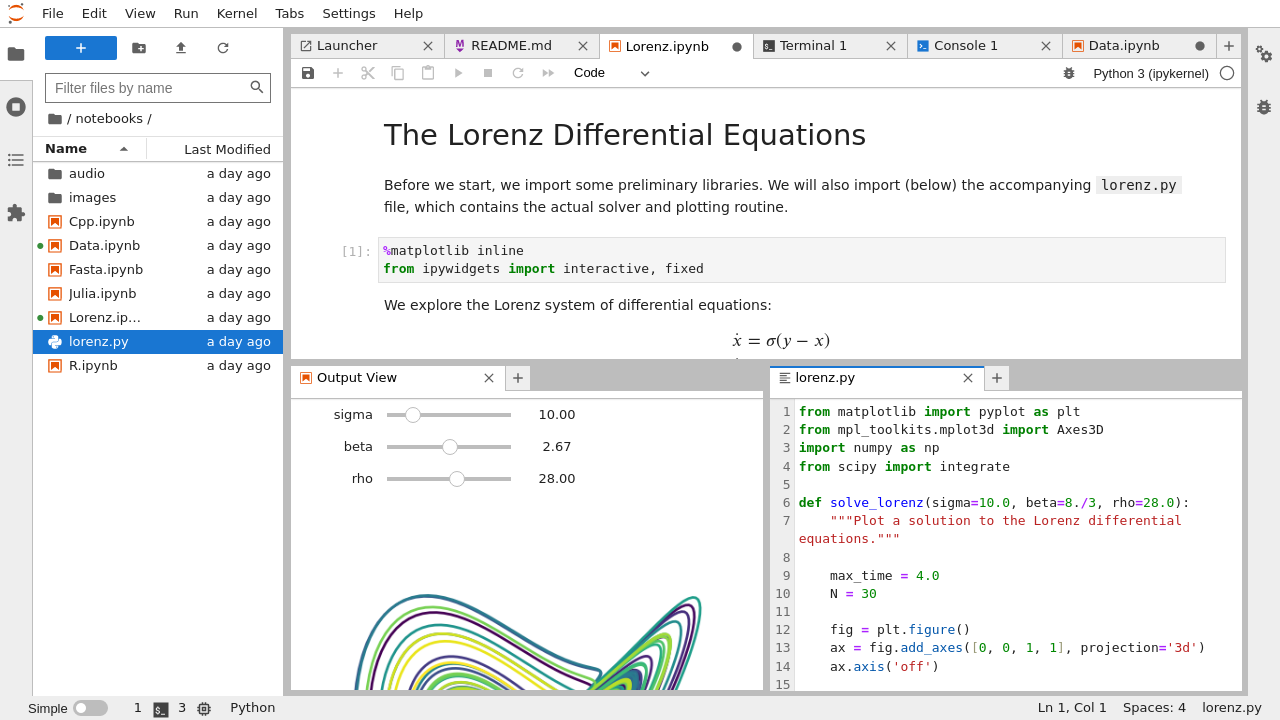

## 2. Code Cell

A code cell contains Python code that can be executed.

In [ ]:
print("Hello, CME538!")

### What happened?

When you run a code cell, Python executes the code and displays the result below the cell.

Try changing the message and run the cell again.

*Change the message to something about yourself or your project interests.*

## 3. Markdown Cells

Markdown cells are used for text, explanations, headings, lists, equations, and other documentation.

They do not execute Python code.

# Main Heading

## Subheading

This is **bold** text.

This is *italic* text.

- Item 1
- Item 2
- Item 3

*Add your own Markdown heading and a one-sentence description of something you would like to analyze using data.*


## 4. Variables

In [ ]:
temperature = 18
rainfall = 12.5
location = "Toronto"

print(temperature)
print(rainfall)
print(location)

A variable stores a value that we can use later in our program.

Variables can store different types of information, including numbers and text.

In [ ]:
project_name = "CME538"

In [ ]:
print(project_name)

## 5. Notebook State

In [ ]:
#cell 1:

x = 10

In [ ]:
# cell 2:
x + 5

The notebook remembers variables created in previously executed cells.

This is useful, but it can also cause problems if cells are executed out of order.

In [ ]:
x = 100

In [ ]:
x + 5


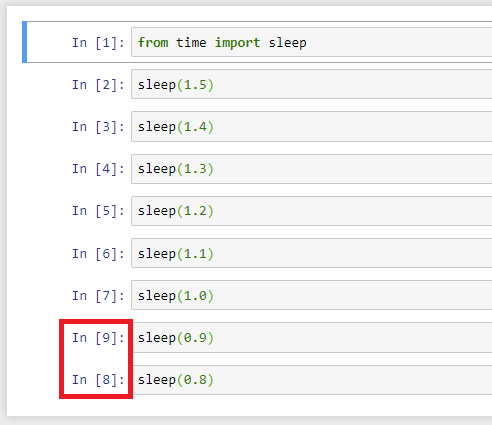

## 6. Restarting and Running the Notebook

The notebook keeps variables in memory while the kernel is running.

If your notebook behaves unexpectedly, restarting the kernel and running the notebook from the beginning can help identify problems.

For example, if you see:
NameError: name 'x' is not defined

Python is telling you that it does not currently know what x is.

This can happen if:
- you have not run the cell that creates x;
- you restarted the kernel; or
- you executed cells in an unexpected order.

**Good habit**

When your notebook starts behaving strangely:
- Restart the kernel.
- Run the cells from the beginning.
- Check where the error occurs.

## 7. Functions

A function is a reusable piece of code that performs a particular task.
We have already used a function:

print("Hello, CME538!")

Here, print() is a Python function.

We can also create our own functions.

In [ ]:
# For example, suppose we want to calculate a change in temperature.

def temperature_change(start_temperature, end_temperature): 
    """Calculate the change in temperature.""" 
    return end_temperature - start_temperature

In [ ]:
change = temperature_change(18, 25) 
print("Temperature change:", change, "°C")

## 8. Libraries and Imports

Python has many built-in capabilities, but data science often requires additional functionality provided by libraries.

A library is a collection of code written by other developers that we can reuse in our own programs.

For example, pandas is a Python library commonly used for working with tables of data.
We make a library available in our notebook using import.

In [ ]:
# pandas is a Python library commonly used for working with tables of data. 
import pandas as pd

## 9. A Small Data Science Example

Imagine that a sensor is monitoring a piece of equipment.
Every two minutes, the system records:
time;
temperature;
vibration; and
pressure.

Our goal is not to perform a sophisticated analysis.

Instead, we will practice a basic data-science workflow:

Load data
    ↓
Inspect data
    ↓
Ask a question
    ↓
Calculate something
    ↓
Visualize the data
    ↓
Interpret the result

In [1]:
# pandas is a Python library commonly used for working with tables of data.
import pandas as pd

In [ ]:
#installing a new library
!pip install pandas

In [3]:
# Read the CSV file and store the data in a pandas DataFrame.
data = pd.read_csv("data/Sensor_data.csv")

data

,time_min,temperature_C,vibration_mm_s,pressure_kPa
0,0,22.1,1.2,101.2
1,2,22.8,1.3,101.5
2,4,23.4,1.2,101.7
3,6,24.2,1.4,102.0
4,8,25.1,1.5,102.4
5,10,26.0,1.6,102.7
6,12,27.2,1.7,103.0
7,14,28.0,1.8,103.4
8,16,28.7,1.7,103.1
9,18,29.5,1.9,103.8


In [ ]:
# Look at the first five measurements.
data.head()

In [ ]:
# How many measurements and variables do we have?
data.shape

In [ ]:
# Calculate basic statistics for the numerical columns.
data.describe()


In [ ]:
# What is the average temperature during the experiment?

# First, select the temperature column:
# Select the temperature measurements.

data["temperature_C"]

#Now calculate the average:

# Calculate the average temperature.
data["temperature_C"].mean()

#The .mean() function calculates the arithmetic mean.

In [ ]:
# Try It Yourself
#What is the average vibration measurement?

# Write your code here.


#Hint:
# You need to select the vibration_mm_s column and calculate its mean.

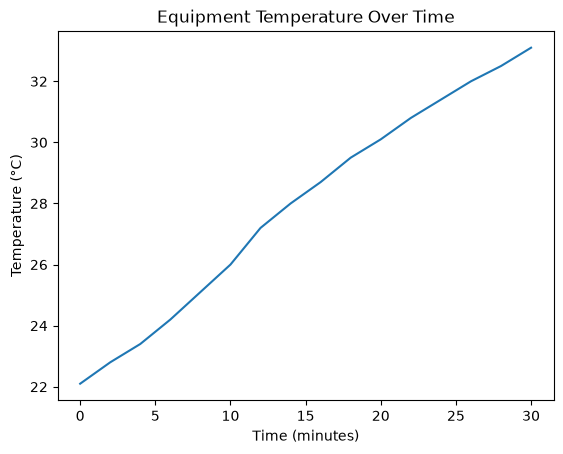

In [9]:
# Import Matplotlib, a Python library for creating visualizations.
import matplotlib.pyplot as plt

# Plot temperature against time.
plt.plot(data["time_min"], data["temperature_C"])

# Add labels so the plot is easier to understand.
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.title("Equipment Temperature Over Time")

plt.show()

In [5]:
# A function lets us package a calculation so that we can reuse it.
def temperature_change(start_temperature, end_temperature):
    """Calculate the change in temperature."""
    return end_temperature - start_temperature

In [6]:
# Calculate the temperature change during the experiment.
change = temperature_change(
    data["temperature_C"].iloc[0],
    data["temperature_C"].iloc[-1]
)

print("Temperature change:", change, "°C")

Temperature change: 11.0 °C


### Checking the Temperature Trend

We can compare the first and last temperature measurements to check whether the equipment warmed up or cooled down during the experiment.

In [7]:
# Get the temperature from the first measurement in the DataFrame.
initial_temperature = data["temperature_C"].iloc[0]

# Get the temperature from the last measurement in the DataFrame.
final_temperature = data["temperature_C"].iloc[-1]

# Use the function defined above to calculate the change in temperature.
temperature_difference = temperature_change(
    initial_temperature, final_temperature
)

# Compare the first and last temperatures to describe the overall change.
if final_temperature > initial_temperature:
    trend_message = "increased"
elif final_temperature < initial_temperature:
    trend_message = "decreased"
else:
    trend_message = "stayed the same"

# Print a short interpretation that is easy to read.
print(f"Initial temperature: {initial_temperature:.2f} °C")
print(f"Final temperature: {final_temperature:.2f} °C")
print(f"Temperature change: {temperature_difference:.2f} °C")
print(f"Overall, the equipment temperature {trend_message} during the experiment.")

Initial temperature: 22.10 °C
Final temperature: 33.10 °C
Temperature change: 11.00 °C
Overall, the equipment temperature increased during the experiment.


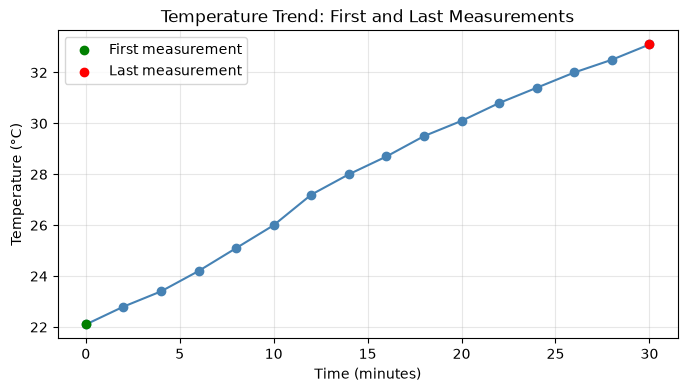

In [10]:
# Create a second plot with markers for every measurement.
plt.figure(figsize=(8, 4))
plt.plot(
    data["time_min"],
    data["temperature_C"],
    marker="o",
    color="steelblue"
)

# Highlight the first and last measurements being compared.
plt.scatter(data["time_min"].iloc[0], initial_temperature, color="green", label="First measurement", zorder=3)
plt.scatter(data["time_min"].iloc[-1], final_temperature, color="red", label="Last measurement", zorder=3)

# Add labels and a legend to make the trend easy to interpret.
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Trend: First and Last Measurements")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Interpret the Result

## What do you see?

Look at the visualization you just created.

Write 1–2 observations in the Markdown cell below.

**Do not worry about whether your observation is "correct."**
The goal is to practice looking at data and describing what you see.

## 10. Reusing and Finding Code

## Finding Help

You will frequently encounter functions or errors that you do not immediately understand.

Useful sources include:

- Course materials
- Official Python/library documentation
- U of T resources
- Search engines and programming communities
- Documentation provided by software packages
- AI-assisted programming tools


In [ ]:
help(pd.read_csv)

In [ ]:
pd.read_csv?

## 11. AI-Assisted Coding

## AI-Assisted Coding

Modern data science workflows increasingly include AI-assisted programming tools.

AI tools can help you:

- understand unfamiliar code,
- generate code,
- debug errors,
- improve code structure,
- explore alternative approaches.

However, AI-generated code is not automatically correct.

You are responsible for understanding, testing, and verifying any code you use.